## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader, CSVLoader
from redoxed.plots import NyquistPlot, DRTPlot, ResidualsPlot, PolarisationPlot
from redoxed.impedance import EISData, DRTData, ResidualsData
from redoxed.impedance.drt_analysis import HN_Z, HN_DRT, SG_DRT, fit_DRT_peaks, find_DRT_peaks, Z_from_DRT, extend_logspace_f
from redoxed.dc import PolarisationData
from redoxed.impedance.drt_solver import DRT_rr_solver

from redoxed import config
config.set_latex_mode(False) # warning, slows plotting if True. Used to achieve consistent serif fonts by rendering latex. 

# Z-HIT
from pyimpspec import perform_zhit, ZHITResult, DataSet
# # circuit fit
# from pyimpspec import (
#     ComplexImpedances,    # Alias for a NumPy array of complex128 values
#     Frequencies,          # Alias for a NumPy array of float64 values
#     Circuit,
#     DataSet,
#     FitResult,
#     Element,              # The base class for all circuit elements
#     ElementDefinition,    # A class that contains information regarding a new circuit element
#     ParameterDefinition,  # A class that contains information regarding a circuit element's parameter
#     register_element,     # A function that processes the new element class
#     parse_cdc,
#     fit_circuit,
# )

%matplotlib inline
# %matplotlib qt

# if think is slowing down, disable autoreload by restarting kernel without it.
%load_ext autoreload
%autoreload 2 

# Get tab10 colors and names (colorblind friendly)
cmap = plt.get_cmap('tab10')
tab10_names = [
    "blue", "orange", "green", "red", "purple",
    "brown", "pink", "gray", "olive", "cyan"]
tab10_colors = cmap.colors
# Create a name-to-color dictionary
colour_dict = dict(zip(tab10_names, tab10_colors))
colour_dict["black"] = (0, 0, 0) # add black color

## Load Data

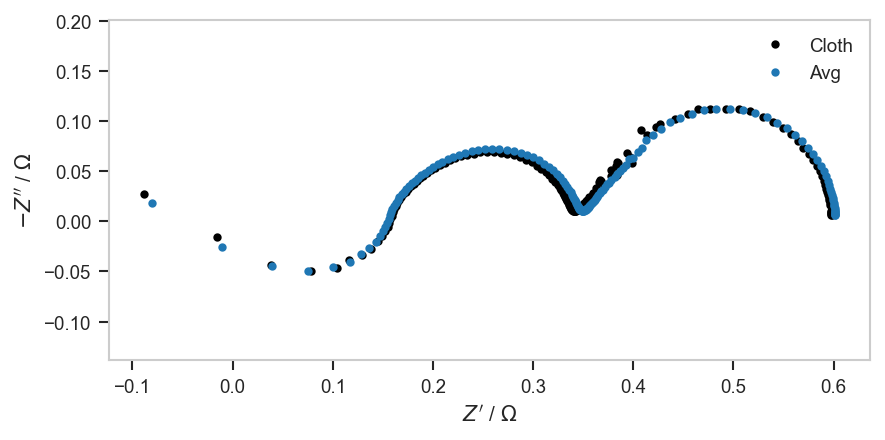

In [ ]:
# initialise plot dictionaries
eis_plot_dict = {}
residuals_plot_dict = {}
drt_plot_dict = {}

#########################
##### Data loading ######
#########################
label = "Cloth"
fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.06.15 FB2_FCN_KCl_E620K_1186HCB\17_replelec_C04.mpr"
#fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.05.06 FB2_FCN_KCl_E620K_1186HCB\4_50ml_200mM_FCN_33rpm_03_GEIS_C04.mpr"
#fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.03.06 FB1_FCN_KCl_E620K_GFDBO_B3cutedge\1_50ml_50soc_20mM_FCN_33rpm_air_03_GEIS_C02.mpr"

ECData_object = BiologicLoader().load_data(fpath=fpath)
# print(ECData_object.df["cycle number"].to_numpy()[-1])
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 2)
EISData_object = ECData_object.to_EISData()
# EISData_object.crop_frequency(0.01, 2e5)
#EISData_object.crop_frequency(1e5, 2e5)
EISData_object.label = label
eis_plot_dict[EISData_object.label] = {
        "data": EISData_object,
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "", "marker": ".", "label": EISData_object.label},
        "plot": True
    }

ECData_object = BiologicLoader().load_data(fpath=fpath)
EISData_object = ECData_object.average_to_EISData(cycle_range=(1, 50), label="Avg")
eis_plot_dict[EISData_object.label] = {
        "data": EISData_object,
        "plot_kwargs": {"color": colour_dict["blue"], "linestyle": "", "marker": ".", "label": EISData_object.label},
        "plot": True
    }


#########################
## Create Nyquist Plot ##
#########################
NyquistPlot_object = NyquistPlot(figsize=(6, 3), dpi = 150) 
for label, entry in eis_plot_dict.items():
    if entry["plot"]:
        NyquistPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
NyquistPlot_object.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# NyquistPlot_object.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
# # Best way is to control size using adjustable = "datalim", and then plot invisible points to ensure points are in view if desired. Less useful for cropping.
# # NyquistPlot_object.ax.grid(True)
# NyquistPlot_object.add_major_ticks(spacing_x = 1, spacing_y = 1)
# # NyquistPlot_object.add_minor_ticks(number_x = 5, number_y = 5)
# NyquistPlot_object.ax.set_ylim(-0.1, 0.2)
# NyquistPlot_object.ax.set_xlim(-0.1, 1)
NyquistPlot_object.ax.legend()
NyquistPlot_object.fig.tight_layout() # try stop cutting off labels
display(NyquistPlot_object.fig)
# NyquistPlot_object.save("Nyquist.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels




## Z-HIT

,Label,Value
0,Log pseudo chi-squared,0.369945
1,Smoothing,modsinc
2,Interpolation,makima
3,Window,flattop


,Label,Value
0,Log pseudo chi-squared,0.367823
1,Smoothing,modsinc
2,Interpolation,makima
3,Window,flattop


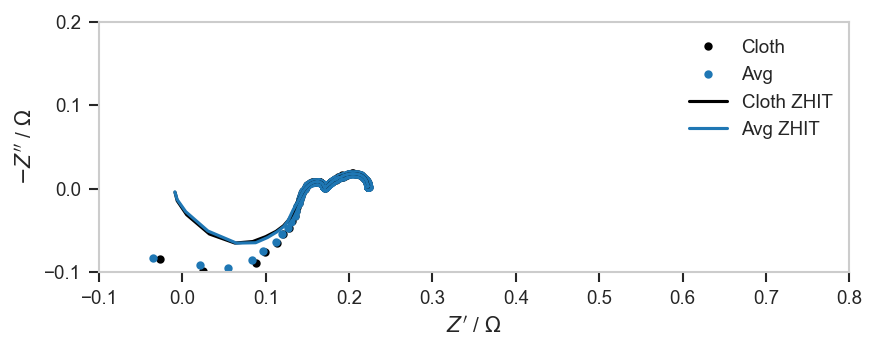

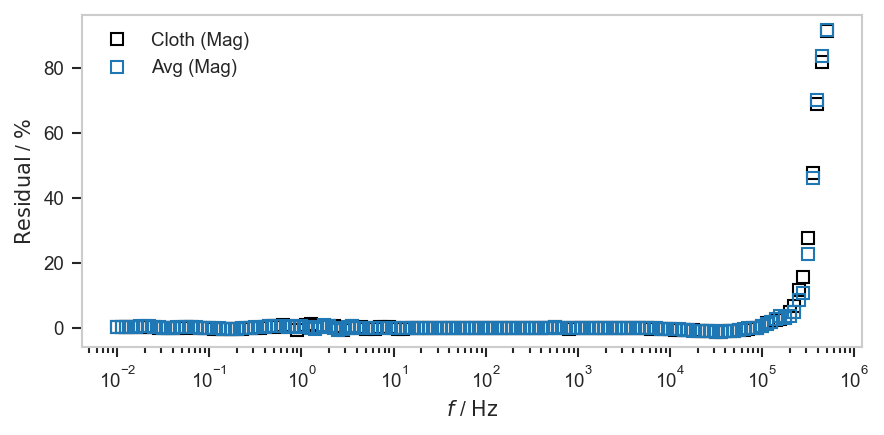

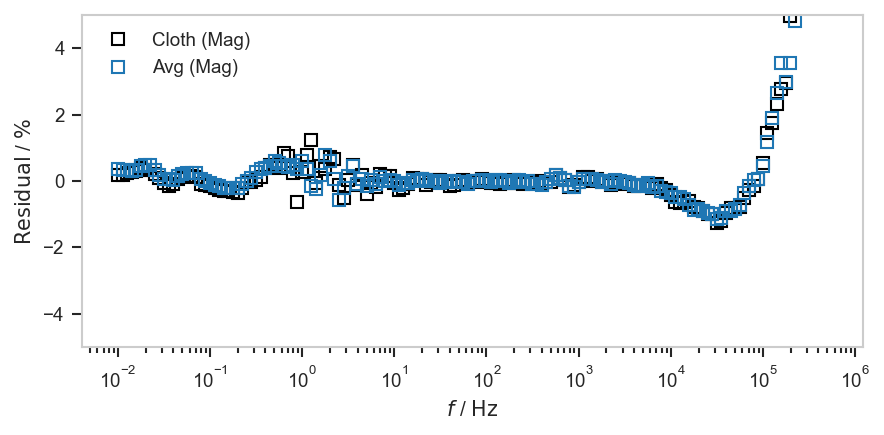

In [3]:

#####################################
##### ZHIT fitting + residuals ######
#####################################
keys_to_consider = ["Cloth", "Avg"]  # or any list of keys you want

for key in keys_to_consider:
    entry_dict = eis_plot_dict[key]
    EISData_object = entry_dict["data"]
    data: DataSet = DataSet(frequencies = EISData_object.f, impedances= EISData_object.Z, mask = None, path = "", label = EISData_object.label, uuid = "")
    # important to set center and width to cover frequency range well.
    # default is center = 1.5 and width = 3 (1-1000 Hz)
    # I prefer center 2.5 (10-10,000 Hz) as the region minimally affected by artefacts 
    zhit: ZHITResult = perform_zhit(data, center = 2.5, width = 3.0) 
    EISData_zhit = EISData(zhit.get_impedances(), f = zhit.get_frequencies(), label = f"{EISData_object.label} ZHIT")
    eis_plot_dict[EISData_zhit.label] = {
            "data": EISData_zhit,
            "plot_kwargs": {"color": entry_dict["plot_kwargs"]["color"], "linestyle": "-", "marker": "", "label": EISData_zhit.label},
            "plot": True
        }
    ## show results
    df = zhit.to_statistics_dataframe()
    statistics = df
    display(statistics)
    ## calculate residuals
    observed = EISData_object
    predicted = EISData_zhit
    residuals_plot_dict[EISData_object.label] = {
            "data": ResidualsData().calculate_residuals(observed = observed, predicted = predicted),
            "plot_kwargs": {"color": entry_dict["plot_kwargs"]["color"], "linestyle": "", "mfc": "none", "label": EISData_object.label},
            "plot": True
        }

#########################
## Create Nyquist Plot ##
#########################
NyquistPlot_object = NyquistPlot(figsize=(6, 3), dpi = 150) 
for label, entry in eis_plot_dict.items():
    if entry["plot"]:
        NyquistPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
# NyquistPlot_object.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
NyquistPlot_object.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
# # Best way is to control size using adjustable = "datalim", and then plot invisible points to ensure points are in view if desired. Less useful for cropping.
# # NyquistPlot_object.ax.grid(True)
# NyquistPlot_object.add_major_ticks(spacing_x = 1, spacing_y = 1)
# # NyquistPlot_object.add_minor_ticks(number_x = 5, number_y = 5)
NyquistPlot_object.ax.legend()
NyquistPlot_object.fig.tight_layout() # try stop cutting off labels
NyquistPlot_object.ax.set_ylim(-0.1, 0.2)
NyquistPlot_object.ax.set_xlim(-0.1, 0.8)
display(NyquistPlot_object.fig)
# NyquistPlot_object.save("Nyquist.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

###########################
## Create Residuals Plot ##
###########################
ResidualsPlot_object = ResidualsPlot(figsize=(6, 3), dpi = 150, mode = 'relative', Z_rep='polar') # gets a bit misleading for small Z
#ResidualsPlot_object = ResidualsPlot(figsize=(3.543, 3), dpi = 150, mode = 'relative',  Z_rep='cartesian')
for label, entry in residuals_plot_dict.items():
    if entry["plot"]:
        if ResidualsPlot_object.Z_rep == 'polar':
            # disable phase plotting
            entry["data"].residuals_phase = None
            entry["data"].residuals_phase_rel = None
            ResidualsPlot_object.ax_phase.set_visible(False)
        # plot
        ResidualsPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
ResidualsPlot_object.fig.tight_layout() # try stop cutting off labels
ResidualsPlot_object.ax.legend()
display(ResidualsPlot_object.fig)
# ResidualsPlot_object.fig.show() # use with qt, only loads after rest of cell executes so with crops
ResidualsPlot_object.ax.set_ylim([-5, 5])
# ResidualsPlot_object.ax_phase.set_ylim([-5, 5])
ResidualsPlot_object.fig.tight_layout() # try stop cutting off labels
ResidualsPlot_object.ax.legend()
display(ResidualsPlot_object.fig)

## DRT

lambda: 0
R0: 0.13809655871692517
L0: 3.169192281028796e-08
C0: nan


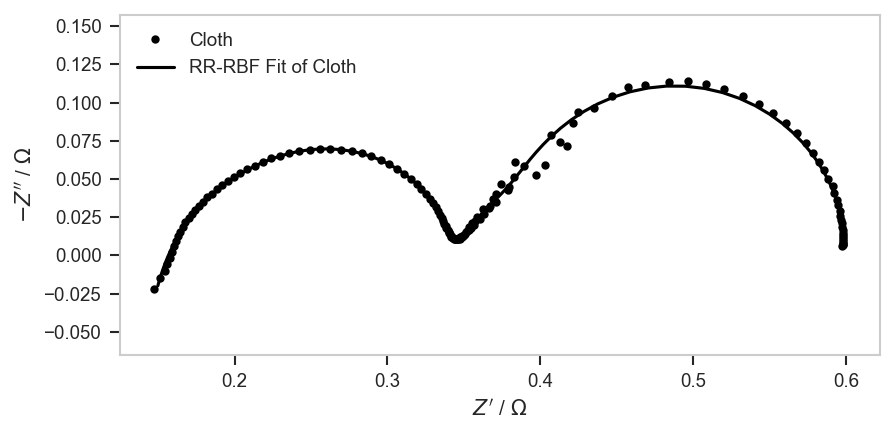

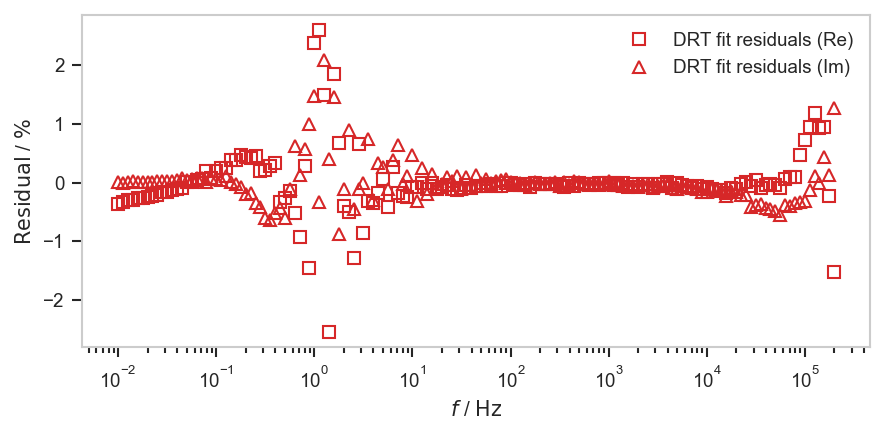

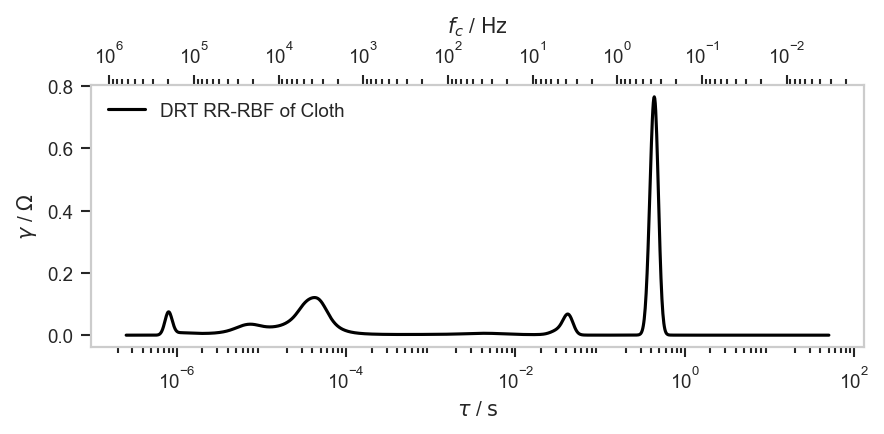

In [5]:
# initialise plot dictionaries

eis_plot_dict = {}
residuals_plot_dict = {}
drt_plot_dict = {}

#########################
##### Data loading ######
#########################

# eis_plot_dict = {k: v for i, (k, v) in enumerate(eis_plot_dict.items()) if i == 0}
# key = list(eis_plot_dict.keys())[0]
# EISData_object = eis_plot_dict[key]["data"]

label = "Cloth"
fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.06.15 FB2_FCN_KCl_E620K_1186HCB\17_replelec_C04.mpr"
#fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.05.06 FB2_FCN_KCl_E620K_1186HCB\4_50ml_200mM_FCN_33rpm_03_GEIS_C04.mpr"
#fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.03.06 FB1_FCN_KCl_E620K_GFDBO_B3cutedge\1_50ml_50soc_20mM_FCN_33rpm_air_03_GEIS_C02.mpr"
ECData_object = BiologicLoader().load_data(fpath=fpath)
# print(ECData_object.df["cycle number"].to_numpy()[-1])
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
EISData_object = ECData_object.to_EISData()
# EISData_object.crop_frequency(0.01, 2e5)
#EISData_object.crop_frequency(1e5, 2e5)
EISData_object.label = label
eis_plot_dict[EISData_object.label] = {
        "data": EISData_object,
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "", "marker": ".", "label": EISData_object.label},
        "plot": True
    }

#########################
###### DRT fitting ######
#########################

EISData_object.crop_frequency(0.01, 2e5)

# f_expanded = extend_logspace_f(EISData_object.f, 0.01, 2e6)
# tau_l_vec = 1 / (2 * np.pi * f_expanded)
tau_l_vec = None # use default if None
lambda_value = 0
lambda_selection = 'fixed' # 'gcv' or 'fixed' recommended
lambda_optimization = {
            "method": "L-BFGS-B",
            "bounds": [(np.log(1e-12), np.log(1e0))],
            "options": {"disp": True, "maxiter": 2000},
        }
quad_opts = {"a": -30, "b": 30, "epsabs": 1e-9, "epsrel": 1e-9}

DRT_solver_object = DRT_rr_solver(EISData_object=EISData_object, tau_l_vec = tau_l_vec, lambda_value = lambda_value, lambda_selection = lambda_selection, lambda_optimization = lambda_optimization, quad_opts = quad_opts)
DRT_solver_object.calculate_drt()
EISData_fit = DRT_solver_object.EISData_fit
DRTData_fit = DRT_solver_object.DRTData_fit

# print lumped elements and lambda used nicely formatted
print(f'lambda: {DRT_solver_object.lambda_value}')
print(f'R0: {DRTData_fit.R0}')
print(f'L0: {DRTData_fit.L0}')
print(f'C0: {DRTData_fit.C0}')

drt_plot_dict[DRTData_fit.label] = {
        "data": DRTData_fit,
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "-", "marker": "", "label": DRTData_fit.label},
        "plot": True
    }
eis_plot_dict[EISData_fit.label] = {
        "data": EISData_fit,
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "-", "marker": "", "label": EISData_fit.label},
        "plot": True
    }

#########################
#### Fitted Residuals ###
#########################

observed = EISData_object
predicted = EISData_fit
residuals_plot_dict[EISData_object.label] = {
        "data": ResidualsData().calculate_residuals(observed = observed, predicted = predicted),
        "plot_kwargs": {"color": colour_dict["red"], "linestyle": "", "mfc": "none", "label": "DRT fit residuals"},
        "plot": True
    }

#########################
## Create Nyquist Plot ##
#########################
NyquistPlot_object = NyquistPlot(figsize=(6, 3), dpi = 150) 
for label, entry in eis_plot_dict.items():
    if entry["plot"]:
        NyquistPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
NyquistPlot_object.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# # NyquistPlot_object.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
# # Best way is to control size using adjustable = "datalim", and then plot invisible points to ensure points are in view if desired. Less useful for cropping.
# # NyquistPlot_object.ax.grid(True)
# NyquistPlot_object.add_major_ticks(spacing_x = 1, spacing_y = 1)
# # NyquistPlot_object.add_minor_ticks(number_x = 5, number_y = 5)
NyquistPlot_object.ax.legend()
NyquistPlot_object.fig.tight_layout() # try stop cutting off labels
display(NyquistPlot_object.fig)
# NyquistPlot_object.save("Nyquist.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

###########################
## Create Residuals Plot ##
###########################
ResidualsPlot_object = ResidualsPlot(figsize=(6, 3), dpi = 150, mode = 'relative',  Z_rep='cartesian') # gets a bit misleading for small Z
for label, entry in residuals_plot_dict.items():
    if entry["plot"]:
        # if ResidualsPlot_object.Z_rep == 'polar':
        #     # disable phase plotting
        #     entry["data"].residuals_phase = None
        #     entry["data"].residuals_phase_rel = None
        #     ResidualsPlot_object.ax_phase.set_visible(False)
        # plot
        ResidualsPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
# ResidualsPlot_object.ax.set_ylim([-5, 5])
# ResidualsPlot_object.ax_phase.set_ylim([-5, 5])
ResidualsPlot_object.fig.tight_layout() # try stop cutting off labels
ResidualsPlot_object.ax.legend()
display(ResidualsPlot_object.fig)

#########################
#### Create DRT Plot ####
#########################
DRTPlot_object = DRTPlot(figsize=(6, 3), dpi = 150)
for label, entry in drt_plot_dict.items():
    if entry["plot"]:
        DRTPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
# DRTPlot_object.add_major_ticks(spacing_y = 1)
# DRTPlot_object.add_minor_ticks(number_x = 9)
DRTPlot_object.add_fc_axis() # only use after enforcing DRTPlot_object.ax.set_xlim([0, None]) if desired
DRTPlot_object.ax.legend()
DRTPlot_object.fig.tight_layout() # try stop cutting off labels
display(DRTPlot_object.fig)
# DRTPlot_object.save("DRT.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

eis_plot_dict_store = eis_plot_dict.copy()
drt_plot_dict_store = drt_plot_dict.copy()
NyquistPlot_object_store = NyquistPlot_object.copy()
DRTPlot_object_store = DRTPlot_object.copy()

## Peak Fitting

Looking for up to  None  peaks


[(np.float64(8.0458035559429e-07), np.float64(0.07497894232006114)),
 (np.float64(7.440073986215349e-06), np.float64(0.03527566740058398)),
 (np.float64(4.251731648840396e-05), np.float64(0.12082369662783278)),
 (np.float64(0.00424982970866705), np.float64(0.0060576531644474674)),
 (np.float64(0.04139768275723946), np.float64(0.06782475479573198)),
 (np.float64(0.4359890154908464), np.float64(0.7653933777934975)),
 (np.float64(14.238122684330357), np.float64(5.245394798438044e-05))]

,label,peak_type,peak_number,log_tau0,height,upsilon,sigma,tau0,Z
0,peak_0,SG,0,-14.031178,0.075764,0.026651,0.103051,8.060032e-07,0.019584
1,peak_1,SG,1,-11.812025,0.036963,0.003304,0.626155,7.414859e-06,0.058015
2,peak_2,SG,2,-10.069225,0.118777,0.008554,0.415570,4.236342e-05,0.123737
3,peak_3,SG,3,-5.459609,0.006120,0.002698,1.423271,4.255218e-03,0.021833
4,peak_4,SG,4,-3.178365,0.066773,0.004171,0.151389,4.165371e-02,0.025339
5,peak_5,SG,5,-0.834616,0.768172,0.008926,0.113214,4.340410e-01,0.218013
6,peak_6,SG,6,2.656116,0.000054,-0.106646,8.137852,1.424087e+01,0.000619


{'success': True,
 'message': 'Optimization terminated successfully.',
 'chisqr': np.float64(0.01661247454944815),
 'redchi': np.float64(1.152044004816099e-05),
 'nfev': 11354,
 'method': 'Nelder-Mead',
 'kws sent': {'method': 'Nelder-Mead', 'options': {'maxiter': 116000}}}

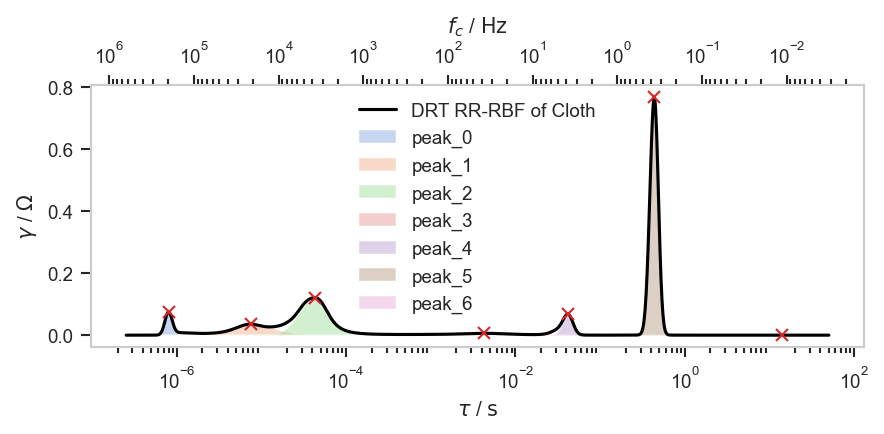

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


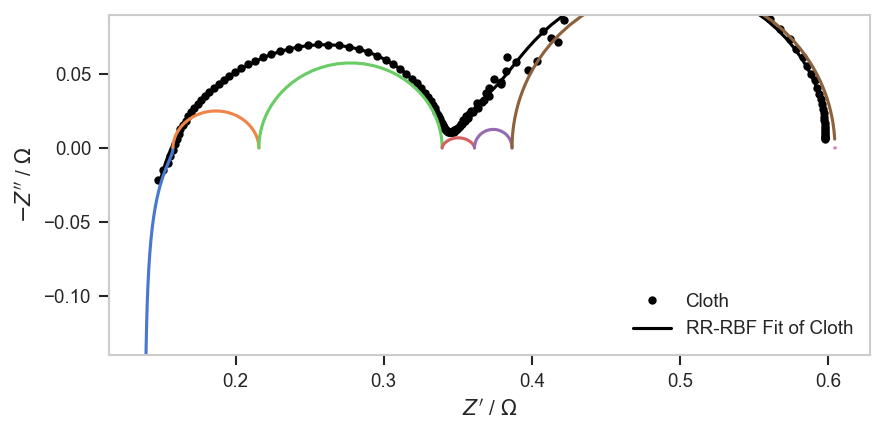

Max data Re:  0.5981415510177612
DRT Rp: 0.46207830462689403
DRT R0: 0.13809655871692517
DRT Rp + R0: 0.6001748633438192
Peak sum Z0: 0.46714124510718597
Peak sum Z0 + R0: 0.6052378038241111
Inductance L: 3.169192281028796e-08


In [9]:
eis_plot_dict = eis_plot_dict_store.copy()
drt_plot_dict = drt_plot_dict_store.copy()
NyquistPlot_object = NyquistPlot_object_store.copy()
DRTPlot_object = DRTPlot_object_store.copy()

##################
## Peak fitting ##
##################
peaks_to_fit = None # auto
#peaks_to_fit = 6
print("Looking for up to ", peaks_to_fit, " peaks")
peak_positions = find_DRT_peaks(DRTData_object = DRTData_fit, num_peaks = peaks_to_fit, find_peaks_settings = dict(height=None, threshold=None, distance=None, prominence=None, width=None, wlen=None, rel_height=0.5, plateau_size=None))

# # insert peak position if desired
# peak_positions.insert(2, (2e-4, 0.03))

display(peak_positions)

for peak_pos in peak_positions:
    DRTPlot_object.add_plot(DRTData(tau = np.array([peak_pos[0]]), gamma = np.array([peak_pos[1]])), color = colour_dict["red"], marker = "x", linestyle = "")

# minimizer_settings = {"method": "leastsq", "fit_kws": {}} # L2 norm better for height
# minimizer_settings = {"method": "powell", "fit_kws": {}} # L1 so better for area
minimizer_settings = {"method": "nelder", "fit_kws": {}} # L1 + initial condtions: best so far
peak_fit = fit_DRT_peaks(
    DRTData_object = DRTData_fit,
    peak_positions = peak_positions, # if make none, uses num_peaks to find
    num_peaks =  None, # None if using peak positions instead
    peak_type = 'SG', # select HN or SG
    skew = True,
    log_tau0_bound = 0.1, # base e not 10 # about ± 10%, made fit much better due to easing contraint on tau0
    assym_bound = 1, # 1 is allow full assymetry, 0 is no skew
    minimizer_settings = minimizer_settings
    )

quad_opts = {'epsabs': 1e-8, 'epsrel': 1e-8, 'limit': 200, 'a': -20, 'b': 5}

df = peak_fit.to_peaks_df(quad_opts=quad_opts)
display(df)
display(peak_fit.fit_summary)

f_expanded = extend_logspace_f(EISData_object.f, 0.01, 5e6)

Z_tot = DRTData_fit.R0 + 1j * 2 * np.pi * f_expanded * DRTData_fit.L0
for i, peak in enumerate(peak_fit):
    # DRTPlot_object.add_plot(DRTData(tau = DRTData_object.tau, gamma = peak.get_gamma(tau=DRTData_object.tau), label = peak.label))
    DRTPlot_object.ax.fill_between(DRTData_fit.tau, peak_fit.get_gamma(tau=DRTData_fit.tau, peak_indices = [i]), 0, where=(peak_fit.get_gamma(tau=DRTData_fit.tau) >= 0), alpha=0.3, label = df[df['peak_number']==i]['label'].values[0])
    peak_type = peak.peak_params['peak_type']
    if peak_type == "HN":
        peak_row = df[df['peak_number']==i]
        alpha = peak_row['alpha'].values[0]
        beta = peak_row['beta'].values[0]
        tau0 = peak_row['tau0'].values[0]
        Z0 = peak_row['Z0'].values[0]
        Z_peak = Z_tot + HN_Z(2*np.pi*f_expanded, Z0, tau0, alpha, beta)
    elif peak_type == "SG":
        # def gamma_func(tau):
        #     return peak.get_gamma(tau)
        #Z_peak = Z_tot + Z_from_DRT(f_expanded, gamma = gamma_func)
        #Z_peak = Z_tot + Z_from_DRT(f_expanded, gamma = peak.get_gamma)
        Z_peak = Z_tot + Z_from_DRT(f_expanded, gamma = peak.get_gamma, quad_opts=quad_opts)
        #Z_peak = Z_tot + Z_from_DRT(f_expanded, gamma = peak.get_gamma(tau = DRTData_fit.tau), tau = DRTData_fit.tau)
    Z_peak_re = np.real(Z_peak)
    Z_peak_im = np.imag(Z_peak)
    Z_tot = Z_peak_re[-1] # update total
    # not using EISData objects as frequency loses meaning
    NyquistPlot_object.ax.plot(Z_peak_re, -Z_peak_im)

DRTPlot_object.ax.legend()
#DRTPlot_object.ax.set_ylim(-0.1, 0.5)
display(DRTPlot_object.fig)
# DRTPlot_object.ax.set_ylim(-0.1, 0.25)
# display(DRTPlot_object.fig)
NyquistPlot_object.ax.set_ylim(-0.1, 0.05)
display(NyquistPlot_object.fig)

print("Max data Re: ", np.max(EISData_object.Z_re))
print("DRT Rp:", DRTData_fit.get_pol_resistance())
print("DRT R0:", DRTData_fit.R0)
print("DRT Rp + R0:", DRTData_fit.get_pol_resistance() + DRTData_fit.R0)
print("Peak sum Z0:", df['Z'].sum())
print("Peak sum Z0 + R0:", df['Z'].sum() + DRTData_fit.R0)
print("Inductance L:", DRTData_fit.L0)